### Ejercicio Ecuación Diferencial

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

: 

Para resolver esta ecuación diferencial de segundo orden utilizando métodos numéricos como los disponibles en scipy.integrate, primero se transforma en un sistema de ecuaciones de primer orden. La ecuación original del sistema masa-resorte es:

$$m\frac{d^2x}{dt^2} + c\frac{dx}{dt} + kx = 0$$

Para hacer la transformación, definimos dos nuevas variables de estado. La primera representará la posición y la segunda la velocidad:

Sea $x_1 = x$ (Desplazamiento)Sea $x_2 = \frac{dx}{dt}$ (Velocidad) si se deriva ambas variables con respecto al tiempo, obtenemos:

$\frac{dx_1}{dt} = \frac{dx}{dt} = x_2$  w          ;                 $\frac{dx_2}{dt} = \frac{d^2x}{dt^2}$

Ahora, despejamos la segunda derivada de la ecuación original:
$$m\frac{d^2x}{dt^2} = -c\frac{dx}{dt} - kx$$

$$\frac{d^2x}{dt^2} = -\frac{c}{m}\frac{dx}{dt} - \frac{k}{m}x$$

Finalmente, sustituimos las variables de estado en esta última expresión. El sistema equivalente de dos ecuaciones de primer orden queda de la siguiente forma:

$$\frac{dx_1}{dt} = x_2$$

$$\frac{dx_2}{dt} = -\frac{c}{m}x_2 - \frac{k}{m}x_1$$


Este es exactamente el sistema que definimos dentro de la función de Python para que el solucionador (RK45) pueda integrarlo paso a paso.

In [3]:
# 1. Definir los parámetros del sistema
m = 20.0  # Masa en kg
k = 20.0  # Constante del resorte en N/m
c_values = [5, 40, 200]  # Coeficientes de amortiguamiento (sub, crítico, sobreamortiguado)
labels = ['Subamortiguado (c=5)', 'Crítico (c=40)', 'Sobreamortiguado (c=200)']

# 2. Condiciones iniciales
x0 = 1.0  # Desplazamiento inicial en m
v0 = 0.0  # Velocidad inicial en m/s
y0 = [x0, v0] # Vector de estado inicial

# 3. Intervalo de simulación
t_span = (0, 15)  # Tiempo de 0 a 15 segundos
# t_eval genera los puntos donde queremos evaluar la solución para tener una curva suave
t_eval = np.linspace(t_span[0], t_span[1], 500)

Se grafica todas las respuestas cambiando el coeficiente de amortiguamiento

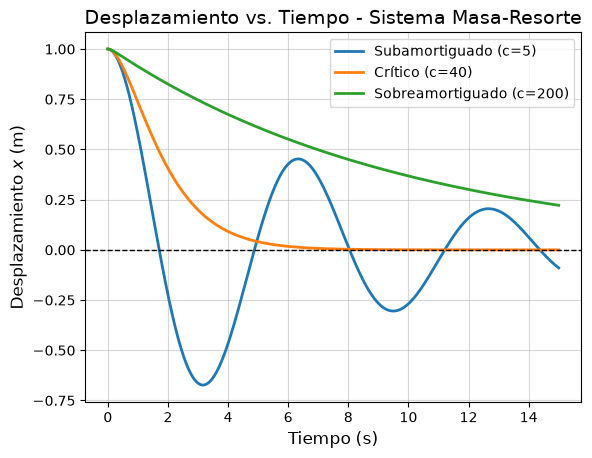

In [7]:
#Resolver la EDO para cada valor de c y graficar
for c, label in zip(c_values, labels):
    
    # La funcion que representa el sistema
    def mass_spring_damper(t, y):
        x_1, x_2 = y
        dxdt = x_2
        dvdt = -(c / m) * x_2 - (k / m) * x_1
        return [dxdt, dvdt]
    
    # Se resuelve usando R45
    sol = solve_ivp(mass_spring_damper, t_span, y0, t_eval=t_eval, method='RK45')
    
    # sol.y[0] contiene el arreglo de posiciones (x_1)
    plt.plot(sol.t, sol.y[0], label=label, linewidth=2)

    # 5. Formato de la gráfica
plt.title('Desplazamiento vs. Tiempo - Sistema Masa-Resorte', fontsize=14)
plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Desplazamiento $x$ (m)', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Línea de equilibrio
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()